In [2]:
!pip install polars

  Using cached polars-1.38.1-py3-none-any.whl.metadata (10 kB)
  Using cached polars_runtime_32-1.38.1-cp310-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (1.5 kB)
Using cached polars-1.38.1-py3-none-any.whl (810 kB)
Using cached polars_runtime_32-1.38.1-cp310-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (45.8 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [polars]2m1/2 [polars]


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import math
import pandas as pd
import polars as pl
import numpy as np
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor
import time
import joblib

In [ ]:
pl.Config.set_tbl_rows(50)

In [4]:
# Read aggregated data from S3
df = pl.read_parquet("s3://msds-26.2-data/clean/combined_recovery_data_aggregated_with_new_features.parquet")

In [5]:
# Drop all week where lag features is null
df = df.drop_nulls(subset=['units_recovered_rolling_mean_12'])

In [6]:
df.describe()

statistic,hashed_fc,gl_product_group,start,end,week_date,year,month,week,num_records,units_RETAIL,units_FBA,units_hazmat,units_food,units_non_food,units_pet_food,units_total,cogs_total,weight_total,country,country_state,zip_code,site_type,site_category,units_recovered,avg_cogs_per_unit,avg_weight_per_unit,cogs_per_unit_weight,share_food,share_non_food,share_pet_food,share_RETAIL,share_FBA,share_hazmat,units_recovered_lag_1,units_recovered_lag_2,units_recovered_lag_4,units_recovered_rolling_mean_4,units_recovered_rolling_std_4,units_recovered_rolling_mean_12,avg_cogs_per_unit_lag_1,avg_weight_per_unit_lag_1,avg_cogs_per_unit_mean_4,avg_weight_per_unit_mean4,units_lag_1,units_mean_4,units_RETAIL_lag_1,units_RETAIL_mean_4,units_FBA_lag_1,units_FBA_mean_4,units_hazmat_lag_1,units_hazmat_mean_4,units_food_lag_1,units_food_mean_4,units_non_food_lag_1,units_non_food_mean_4,units_pet_food_lag_1,units_pet_food_mean_4,share_RETAIL_lag_1,share_RETAIL_mean_4,share_FBA_lag_1,share_FBA_mean_4,share_hazmat_lag_1,share_hazmat_mean_4,share_food_lag_1,share_food_mean_4,share_non_food_lag_1,share_non_food_mean_4,share_pet_food_lag_1,share_pet_food_mean_4,week_sin,week_cos
str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""8050927""",8.050927e6,"""8050927""","""8050927""","""8050927""",8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,"""8050927""","""5083368""","""5080429""","""5083368""","""5083368""",8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6,8.050927e6
"""null_count""","""0""",0.0,"""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""","""2967559""","""2970498""","""2967559""","""2967559""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,263.935462,"""2022-06-20 01:55:31.637263""","""2025-10-10 07:01:18.727182""","""2024-03-25 09:00:31.651759""",2023.719533,6.822143,27.637918,6.625268,1428.468441,2600.889809,297.714019,272.246611,3698.000214,59.111425,4029.35825,31488.957301,4.3658e6,null,null,null,null,null,201.60682,27.21082,3699.455486,0.053763,0.047323,0.947485,0.005192,0.639626,0.360374,0.114214,201.705187,201.476592,201.694444,201.507925,113.619952,201.304816,26.097506,3508.859742,25.700378,3449.803913,4021.951347,3985.255438,1426.122307,1414.322652,2595.829039,2570.932786,296.752195,293.21614,271.350863,268.517957,3691.572295,3658.056466,59.028189,58.681016,0.589808,0.580915,0.33879,0.3363,0.106789,0.105109,0.04452,0.044082,0.879005,0.868089,0.005073,0.005045,-0.042094,-0.02261
"""std""",null,170.980531,null,null,null,1.073267,3.3785,14.769909,11.755244,6437.884302,12525.453744,1973.540204,4141.444074,16600.177986,965.640604,17158.510352,173585.733899,1.5078e7,null,null,null,null,null,1208.294963,109.190337,9340.444035,3.020449,0.212329,0.217628,0.052625,0.402024,0.402024,0.233781,1209.209635,1209.395111,1210.10984,1067.232015,646.183483,1033.21144,107.848017,8657.702842,101.700328,8209.547948,17148.510537,16043.756687,6435.942041,6028.296274,12515.706381,11701.391899,1969.775229,1837.484234,4137.0653,3893.12238,16590.721033,15521.664719,965.115859

In [7]:
df = df.with_columns(units_recovered_prob = pl.col('units_recovered')/pl.col('units_total'))

<Axes: xlabel='units_recovered_prob', ylabel='Count'>

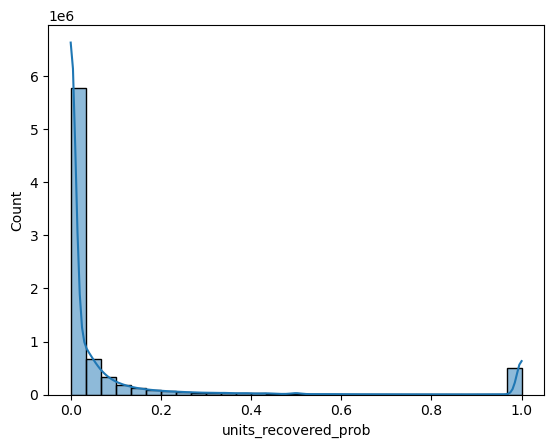

In [9]:
sns.histplot(df, x='units_recovered_prob', kde=True, bins=30)

# 3 Fold Time-Based Cross Validation

In [10]:
# Define features
features_with_current_inventory = [
    "units_total",
    'units_RETAIL',
    'units_FBA',
    'units_hazmat',
    'units_food',
    'units_non_food',
    'units_pet_food',
    'share_food',
    'share_non_food',
    'share_pet_food',
    'share_RETAIL',
    'share_FBA',
    'share_hazmat',
    "units_recovered_lag_1",
    "units_recovered_lag_2",
    "units_recovered_lag_4",
    "units_recovered_rolling_mean_4",
    "units_recovered_rolling_std_4",
    "units_recovered_rolling_mean_12",
    "units_lag_1",
    "units_mean_4",
    'units_RETAIL_lag_1',
    'units_RETAIL_mean_4',
    'units_FBA_lag_1',
    'units_FBA_mean_4',
    'units_hazmat_lag_1',
    'units_hazmat_mean_4',
    'units_food_lag_1',
    'units_food_mean_4',
    'units_non_food_lag_1',
    'units_non_food_mean_4',
    'units_pet_food_lag_1',
    'units_pet_food_mean_4',
    'share_RETAIL_lag_1',
    'share_RETAIL_mean_4',
    'share_FBA_lag_1',
    'share_FBA_mean_4',
    'share_hazmat_lag_1',
    'share_hazmat_mean_4',
    'share_food_lag_1',
    'share_food_mean_4',
    'share_non_food_lag_1',
    'share_non_food_mean_4',
    'share_pet_food_lag_1',
    'share_pet_food_mean_4',
    'avg_cogs_per_unit_lag_1',
    'avg_weight_per_unit_lag_1',
    'avg_cogs_per_unit_mean_4',
    'avg_weight_per_unit_mean4',
    'hashed_fc',
    'gl_product_group',
    'week_sin',
    'week_cos',
    'country',
    'country_state',
    'site_type',
    'site_category',
]

features_with_lag_only = [
    "units_recovered_lag_1",
    "units_recovered_lag_2",
    "units_recovered_lag_4",
    "units_recovered_rolling_mean_4",
    "units_recovered_rolling_std_4",
    "units_recovered_rolling_mean_12",
    "units_lag_1",
    "units_mean_4",
    'units_RETAIL_lag_1',
    'units_RETAIL_mean_4',
    'units_FBA_lag_1',
    'units_FBA_mean_4',
    'units_hazmat_lag_1',
    'units_hazmat_mean_4',
    'units_food_lag_1',
    'units_food_mean_4',
    'units_non_food_lag_1',
    'units_non_food_mean_4',
    'units_pet_food_lag_1',
    'units_pet_food_mean_4',
    'share_RETAIL_lag_1',
    'share_RETAIL_mean_4',
    'share_FBA_lag_1',
    'share_FBA_mean_4',
    'share_hazmat_lag_1',
    'share_hazmat_mean_4',
    'share_food_lag_1',
    'share_food_mean_4',
    'share_non_food_lag_1',
    'share_non_food_mean_4',
    'share_pet_food_lag_1',
    'share_pet_food_mean_4',
    'avg_cogs_per_unit_lag_1',
    'avg_weight_per_unit_lag_1',
    'avg_cogs_per_unit_mean_4',
    'avg_weight_per_unit_mean4',
    'hashed_fc',
    'gl_product_group',
    'week_sin',
    'week_cos',
    'country',
    'country_state',
    'site_type',
    'site_category',
]

In [11]:
# Extract ordered weeks
weeks = (
    df
    .select("week_date")
    .unique()
    .sort("week_date")
    .to_series()
)
n_weeks = len(weeks)

In [12]:
# CV parameters
# Fold 1: Train year 1 test year 2
# Fold 2: Train year 1-2 test year 3
# Fold 3: Train year 1-3, test year 4
fold_size = n_weeks // 4

folds = [
    (weeks[:fold_size], weeks[fold_size:2*fold_size]),
    (weeks[:2*fold_size], weeks[2*fold_size:3*fold_size]),
    (weeks[:3*fold_size], weeks[3*fold_size:])
]

## Predict proportion of units that entered recovery

In [15]:
target_prob = 'units_recovered_prob'

### With current inventory features

In [10]:
results_prob_current = []

for i, (train_weeks, val_weeks) in enumerate(folds):

    train_df = df.filter(pl.col("week_date").is_in(train_weeks))
    val_df = df.filter(pl.col("week_date").is_in(val_weeks))


    X_train = train_df.select(features_with_current_inventory).to_pandas()
    y_train = train_df[target_prob].to_pandas()

    X_val = val_df.select(features_with_current_inventory).to_pandas()
    y_val = val_df[target_prob].to_pandas()


    # Enforce category type
    cat_cols = [
    'hashed_fc',
    'gl_product_group',
    'country',
    'country_state',
    'site_type',
    'site_category'
    ]

    for col in cat_cols:
        X_train[col] = X_train[col].astype("category")
        X_val[col] = X_val[col].astype("category")

    if y_train.mean() == 0:
        print(f"Skipping fold {i+1} (all zero target)")
        continue

    # Fit model
    model_prob_current = XGBRegressor(
        objective="reg:logistic",
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        enable_categorical=True,
        random_state=42
    )

    model_prob_current.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    preds = model_prob_current.predict(X_val)

    mae = mean_absolute_error(y_val, preds)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    r2 = r2_score(y_val, preds)

    results_prob_current.append({
        "fold": i+1,
        "mae": mae,
        "rmse": rmse,
        "r2": r2
    })


/tmp/ipykernel_1998/3020408527.py:5: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  train_df = df.filter(pl.col("week_date").is_in(train_weeks))
/tmp/ipykernel_1998/3020408527.py:6: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  val_df = df.filter(pl.col("week_date").is_in(val_weeks))
/tmp/ipykernel_1998/3020408527.py:5: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  train_df = df.filter(pl.col("week_date").is_in(train_weeks))
/tmp/ipykernel_1998/3020408527.py:6

In [11]:
print(results_prob_current)

[{'fold': 1, 'mae': 0.2754372877181374, 'rmse': np.float64(0.4711740632753401), 'r2': -2.4474235793059984}, {'fold': 2, 'mae': 0.17699911533222892, 'rmse': np.float64(0.3636442127845908), 'r2': -1.2360598543554864}, {'fold': 3, 'mae': 0.07849916084186366, 'rmse': np.float64(0.17048551780754068), 'r2': 0.5125010207471392}]


In [18]:
model_filename = r"DATA5901_26.2/config/model/initial_xgboost_model_current_inventory.joblib"
joblib.dump(model_prob_current, model_filename)

['DATA5901_26.2/config/model/initial_xgboost_model_current_inventory.joblib']

### With only lag features

In [14]:
start_time = time.perf_counter()
results_prob_lag = []

for i, (train_weeks, val_weeks) in enumerate(folds):

    train_df = df.filter(pl.col("week_date").is_in(train_weeks))
    val_df = df.filter(pl.col("week_date").is_in(val_weeks))


    X_train = train_df.select(features_with_lag_only).to_pandas()
    y_train = train_df[target_prob].to_pandas()

    X_val = val_df.select(features_with_lag_only).to_pandas()
    y_val = val_df[target_prob].to_pandas()


    # Enforce category type
    cat_cols = [
    'hashed_fc',
    'gl_product_group',
    'country',
    'country_state',
    'site_type',
    'site_category'
    ]

    for col in cat_cols:
        X_train[col] = X_train[col].astype("category")
        X_val[col] = X_val[col].astype("category")

    if y_train.mean() == 0:
        print(f"Skipping fold {i+1} (all zero target)")
        continue

    # Fit model
    model_prob_lag = XGBRegressor(
        objective="reg:logistic",
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        enable_categorical=True,
        random_state=42
    )

    model_prob_lag.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    preds = model_prob_lag.predict(X_val)

    mae = mean_absolute_error(y_val, preds)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    r2 = r2_score(y_val, preds)

    results_prob_lag.append({
        "fold": i+1,
        "mae": mae,
        "rmse": rmse,
        "r2": r2
    })

end_time = time.perf_counter()
elapsed_time = end_time - start_time

print(f"Elapsed time: {(elapsed_time/60):.2f} minutes")

/tmp/ipykernel_1998/3130348377.py:6: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  train_df = df.filter(pl.col("week_date").is_in(train_weeks))
/tmp/ipykernel_1998/3130348377.py:7: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  val_df = df.filter(pl.col("week_date").is_in(val_weeks))
/tmp/ipykernel_1998/3130348377.py:6: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  train_df = df.filter(pl.col("week_date").is_in(train_weeks))
/tmp/ipykernel_1998/3130348377.py:7

Elapsed time: 11.53 minutes


In [15]:
print(results_prob_lag)

[{'fold': 1, 'mae': 0.2803908391556487, 'rmse': np.float64(0.47331515632721843), 'r2': -2.4788260951555863}, {'fold': 2, 'mae': 0.17660267055293943, 'rmse': np.float64(0.3638683678466877), 'r2': -1.2388173772223108}, {'fold': 3, 'mae': 0.0823084608830596, 'rmse': np.float64(0.1782052696742972), 'r2': 0.4673526025396887}]


In [17]:
model_filename = r"DATA5901_26.2/config/model/initial_xgboost_model_lag_only.joblib"
joblib.dump(model_prob_lag, model_filename)

['DATA5901_26.2/config/model/initial_xgboost_model_lag_only.joblib']

## Feature Importance

### With current inventory

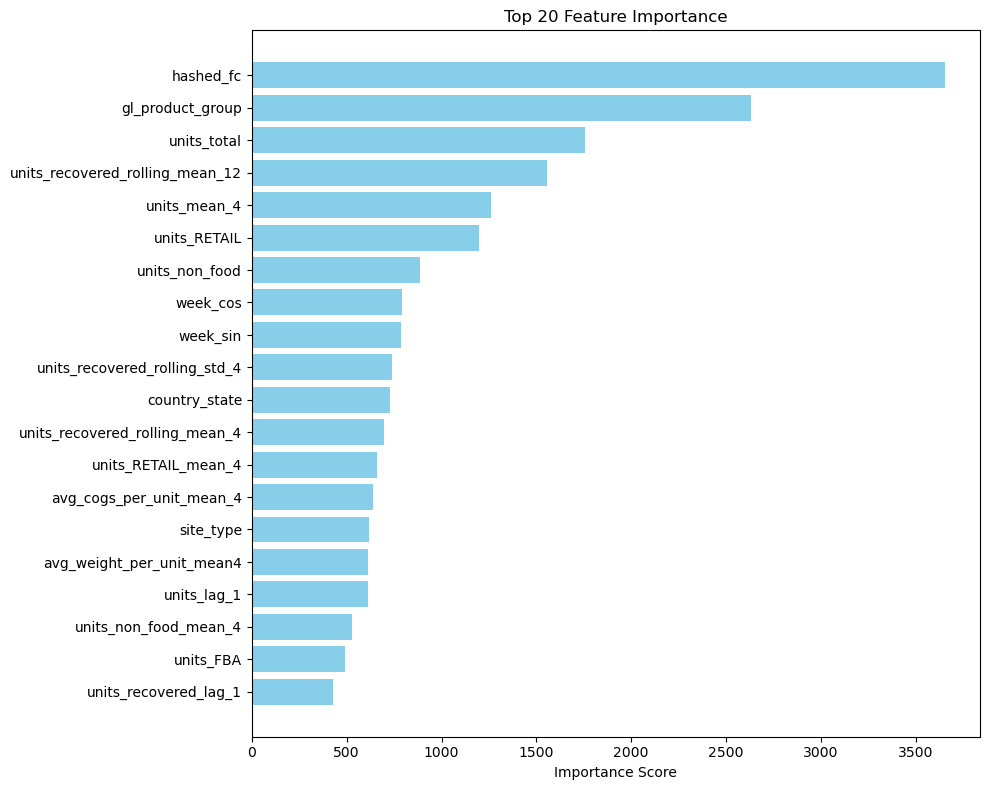

In [19]:
importance = model_prob_current.get_booster().get_score(importance_type='weight')

importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False)

top_n = 20
plt.figure(figsize=(10, 8))
plt.barh(
    importance_df['Feature'].head(top_n)[::-1],
    importance_df['Importance'].head(top_n)[::-1],
    color='skyblue'
)
plt.xlabel('Importance Score')
plt.title(f'Top {top_n} Feature Importance')
plt.tight_layout()
plt.show()

### Without Current Inventory

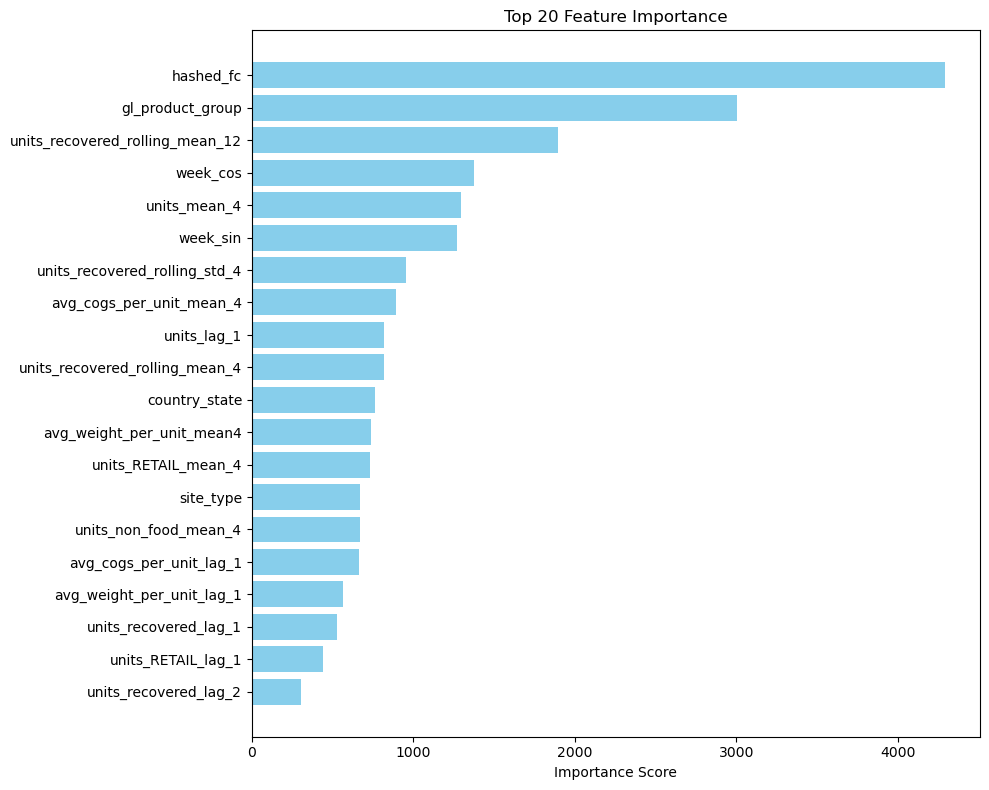

In [21]:
importance = model_prob_lag.get_booster().get_score(importance_type='weight')

importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False)

top_n = 20
plt.figure(figsize=(10, 8))
plt.barh(
    importance_df['Feature'].head(top_n)[::-1],
    importance_df['Importance'].head(top_n)[::-1],
    color='skyblue'
)
plt.xlabel('Importance Score')
plt.title(f'Top {top_n} Feature Importance')
plt.tight_layout()
plt.show()

## Train on logit transformed proportion

In [16]:
eps = 1e-6

In [17]:
start_time = time.perf_counter()
results_prob_current_logit = []

for i, (train_weeks, val_weeks) in enumerate(folds):

    train_df = df.filter(pl.col("week_date").is_in(train_weeks))
    val_df = df.filter(pl.col("week_date").is_in(val_weeks))


    X_train = train_df.select(features_with_current_inventory).to_pandas()
    y_train = train_df[target_prob].to_pandas()

    X_val = val_df.select(features_with_current_inventory).to_pandas()
    y_val = val_df[target_prob].to_pandas()

    # Logit transform
    y_logit_train = np.log((y_train + eps) / (1 - y_train + eps))
    y_logit_val = np.log((y_val + eps) / (1 - y_val + eps))
    
    # Enforce category type
    cat_cols = [
    'hashed_fc',
    'gl_product_group',
    'country',
    'country_state',
    'site_type',
    'site_category'
    ]

    for col in cat_cols:
        X_train[col] = X_train[col].astype("category")
        X_val[col] = X_val[col].astype("category")

    if y_train.mean() == 0:
        print(f"Skipping fold {i+1} (all zero target)")
        continue

    # Fit model
    model_prob_current_logit = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        enable_categorical=True,
        random_state=42
    )

    model_prob_current_logit.fit(
        X_train,
        y_logit_train,
        eval_set=[(X_val, y_logit_val)],
        verbose=False
    )

    preds_logit = model_prob_current_logit.predict(X_val)
    preds = 1/(1+np.exp(-preds_logit))
    preds = np.clip(preds, 0, 1)

    mae = mean_absolute_error(y_val, preds)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    r2 = r2_score(y_val, preds)

    results_prob_current_logit.append({
        "fold": i+1,
        "mae": mae,
        "rmse": rmse,
        "r2": r2
    })

end_time = time.perf_counter()
elapsed_time = end_time - start_time

print(f"Elapsed time: {(elapsed_time/60):.2f} minutes")

/tmp/ipykernel_437/1007401256.py:6: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  train_df = df.filter(pl.col("week_date").is_in(train_weeks))
/tmp/ipykernel_437/1007401256.py:7: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  val_df = df.filter(pl.col("week_date").is_in(val_weeks))
/tmp/ipykernel_437/1007401256.py:6: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  train_df = df.filter(pl.col("week_date").is_in(train_weeks))
/tmp/ipykernel_437/1007401256.py:7: De

Elapsed time: 13.33 minutes


In [18]:
print(results_prob_current_logit)

[{'fold': 1, 'mae': 0.27187054066076266, 'rmse': 0.4833217524465812, 'r2': -2.6274762617301697}, {'fold': 2, 'mae': 0.17022145286269647, 'rmse': 0.376102067856885, 'r2': -1.3918916690635412}, {'fold': 3, 'mae': 0.0839019948977659, 'rmse': 0.22088808103143406, 'r2': 0.18164208107969482}]


## Plot Example Prediction

In [20]:
model_prob_current = joblib.load(r"DATA5901_26.2/config/model/initial_xgboost_model_current_inventory.joblib")

In [29]:
# Make prediction on last 2 week of December 2025
df_example = df.filter((pl.col('year') == 2025) & (pl.col('month') == 12))

X_example = df_example.select(features_with_current_inventory).to_pandas()

# Enforce category type
cat_cols = [
'hashed_fc',
'gl_product_group',
'country',
'country_state',
'site_type',
'site_category'
]

for col in cat_cols:
    X_example[col] = X_example[col].astype("category")

y_example = df_example['units_recovered_prob'].to_pandas()

example_preds = model_prob_current.predict(X_example)

In [30]:
df_example = df_example.with_columns(units_recovered_prob_pred = example_preds)

In [31]:
df_example['hashed_fc'].value_counts().sort(by='count', descending=True)['hashed_fc'][0]

'af3d995c50e41e1251f2fd27dd4e1b9824dbafd1548c97fc59755b02f13b158b'

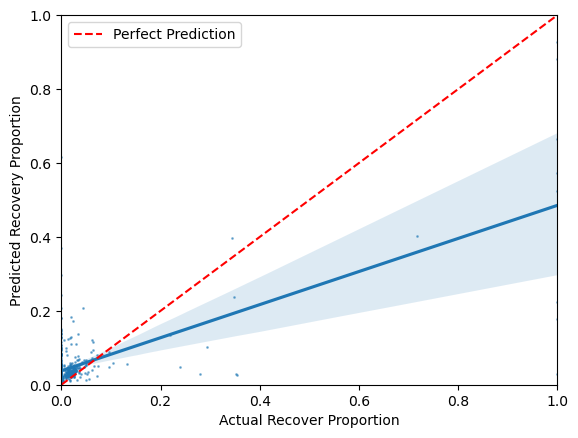

In [34]:
sns.regplot(
    df_example.filter(pl.col('hashed_fc') == 'af3d995c50e41e1251f2fd27dd4e1b9824dbafd1548c97fc59755b02f13b158b'), 
    x='units_recovered_prob', 
    y='units_recovered_prob_pred', 
    scatter_kws={'s': 1, 'alpha': 0.5}
)

# Add the y=x line
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Perfect Prediction')

# Labels and limits
plt.ylabel('Predicted Recovery Proportion')
plt.xlabel('Actual Recover Proportion') 
plt.xlim([0, 1])
plt.ylim([0, 1])

# Optional: add a legend to identify the lines
plt.legend()
plt.show()

In [ ]:
import shap

In [ ]:
explainer = shap.TreeExplainer(model_prob)
shap_values = explainer(X_train)

In [ ]:
shap.plots.beeswarm(shap_values)